# Импорт библиотек

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import json
import joblib


from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import ParameterGrid

from app.forecasting.data.reader import DataReader
from app.forecasting.data.spliter import TemporalSpliter
from app.forecasting.preprocessing.module import PreprocessingModule
from app.forecasting.metrics.metrics import evaluate_model, error_analysis_by_segment
from app.forecasting.postprocessing.uplift import (
    DEFAULT_SALES_UPLIFT_CONFIG,
    apply_sales_uplift_to_log_predictions,
    compute_sales_uplift_fraction,
    high_demand_mask,
)

# Загрузка предобработанных данных

В baseline уже была выполнена предобработка данных. Поэтому просто загрузим предобработанные данные.

In [2]:
X_train = pd.read_csv(PROJECT_ROOT / "data" / "prepared_data" / "X_train.csv")
y_train = pd.read_csv(PROJECT_ROOT / "data" / "prepared_data" / "y_train.csv")
X_val = pd.read_csv(PROJECT_ROOT / "data" / "prepared_data" / "X_val.csv")
y_val = pd.read_csv(PROJECT_ROOT / "data" / "prepared_data" / "y_val.csv")

In [19]:
print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

X_train.columns


(669308, 49)
(175084, 49)
(669308,)
(175084,)


Index(['Promo', 'SchoolHoliday', 'CompetitionDistance', 'Promo2',
       'Competition_is_missing', 'days_since_prev_observation',
       'is_first_observation', 'year', 'month', 'week', 'day', 'dayofweek',
       'is_weekend', 'is_month_start', 'is_month_end', 'quarter', 'season',
       'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7',
       'rolling_mean_14', 'rolling_std_14', 'rolling_mean_28',
       'rolling_std_28', 'lag_7_is_missing', 'lag_14_is_missing',
       'lag_28_is_missing', 'rolling_mean_7_is_missing',
       'rolling_std_7_is_missing', 'rolling_mean_14_is_missing',
       'rolling_std_14_is_missing', 'rolling_mean_28_is_missing',
       'rolling_std_28_is_missing', 'promo2_duration_weeks',
       'is_current_month_in_promo_interval', 'is_state_holiday',
       'competition_duration_months', 'StoreType_a', 'StoreType_b',
       'StoreType_c', 'StoreType_d', 'Assortment_a', 'Assortment_b',
       'Assortment_c', 'StateHoliday_a', 'StateHoliday_b', 'StateHo

# Обучение и предсказание лучшей baseline-модели 

Напомню, что лучшей моделью стал HistGradientBoostingRegressor. Оптимальные гиперпараметры для этой модели были подобраны через GridSearch. Просто получим метрики на valid для baseline.

In [4]:
BEST_PARAMS = {
    "learning_rate": 0.08,
    "max_leaf_nodes": 63,
    "max_iter": 300,
    "l2_regularization": 0.1,
}

if isinstance(y_train, pd.DataFrame):
    y_train = y_train.squeeze()
if isinstance(y_val, pd.DataFrame):
    y_val = y_val.squeeze()

model = HistGradientBoostingRegressor(
    loss="squared_error",
    random_state=42,
    **BEST_PARAMS,
)

model.fit(X_train, y_train)
val_pred = model.predict(X_val)

metrics = evaluate_model(
    "HistGradientBoosting tuned",
    y_val,
    val_pred,
)
metrics

{'model': 'HistGradientBoosting tuned',
 'MAE': 651.9893829716883,
 'RMSE': np.float64(955.1908845158745),
 'RMSPE': np.float64(0.14089043763759299),
 'R2': 0.9022790603506146}

## Сохранение baseline

Сохраним пока так baseline и метрики)

In [5]:
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODELS_DIR / "hgb_baseline.joblib"
joblib.dump(model, model_path)

metrics_path = MODELS_DIR / "hgb_baseline_metrics.json"
metrics_serializable = {
    key: float(value) if isinstance(value, (np.floating, float)) else value
    for key, value in metrics.items()
}
with metrics_path.open("w", encoding="utf-8") as f:
    json.dump(metrics_serializable, f, indent=2)

print(f"Model saved to: {model_path}")
print(f"Metrics saved to: {metrics_path}")

Model saved to: /Users/roman/Desktop/ITMO/MLOps/final_project/ID_forecasting_assistant/models/hgb_baseline.joblib
Metrics saved to: /Users/roman/Desktop/ITMO/MLOps/final_project/ID_forecasting_assistant/models/hgb_baseline_metrics.json


# Анализ ошибок по сегментам

Отобразим реферетную и предсказанную общие суммы продаж по дням. 

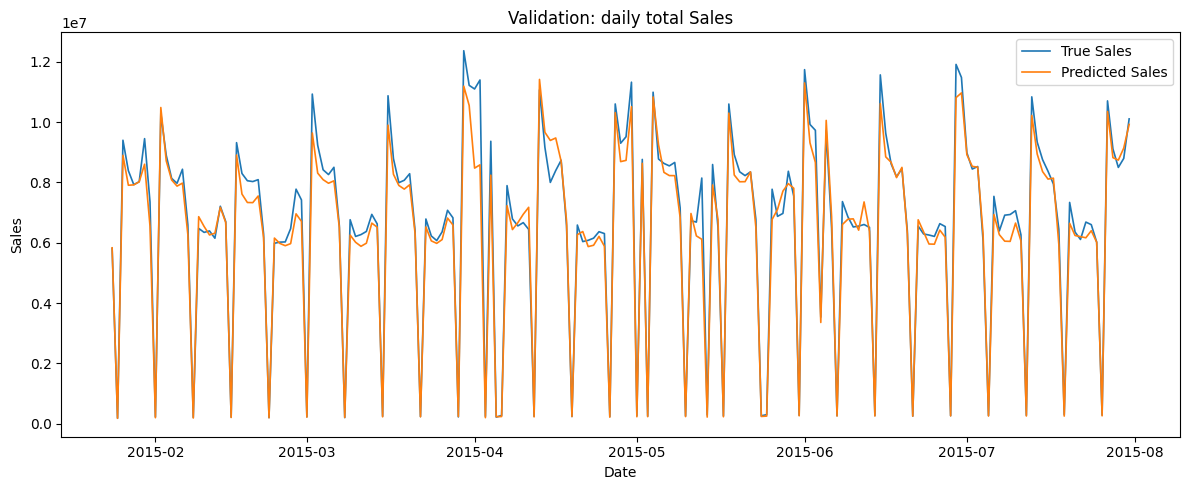

In [6]:
reader = DataReader()
raw_data = reader.read()
split = TemporalSpliter(train_ratio=0.8, val_ratio=0.2).split(raw_data["train"])
preprocessor = PreprocessingModule(use_log=True)
preprocessor.fit(split.train, raw_data["store"])
val_dates = preprocessor.transform(split.val)["Date"]

y_val_sales = np.expm1(y_val)
val_pred_sales = np.clip(np.expm1(val_pred), 0, None)

daily = (
    pd.DataFrame(
        {
            "Date": val_dates.values,
            "y_true": y_val_sales,
            "y_pred": val_pred_sales,
        }
    )
    .groupby("Date", as_index=False)
    .sum()
)

plt.figure(figsize=(12, 5))
plt.plot(daily["Date"], daily["y_true"], label="True Sales", linewidth=1.2)
plt.plot(daily["Date"], daily["y_pred"], label="Predicted Sales", linewidth=1.2)
plt.title("Validation: daily total Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

Для улучшения качества модели было решено сосредоточиться не на усложнении архитектуры, а на усилении признакового пространства и детальном анализе ошибок. Текущая модель уже хорошо описывает основную массу наблюдений, а основная проблема заключается в недооценке экстремально высоких/низких продаж, как видно из графика выше.

## Анализ исходного baseline

1. Формирую errors_df, где для каждого наблюдения сохраняются фактические продажи (y_true), предсказание модели (y_pred) и признаки сегментации.

2. В качестве сегментов использую, например: Promo, StoreType, dayofweek, sales_quantile, StateHoliday, is_month_end.

3. Для каждого сегмента отдельно запускаю функцию error_analysis_by_segment(errors_df, col).

4. По каждому значению сегмента считаю:
    - число наблюдений n
    - MAE
    - RMSE
    - MAPE
    - RMSPE
    - bias
    - долю случаев недопредсказания (underprediction_share)

5. Для наглядности строю bar chart по RMSE в разрезе сегментов.
6. Объединяю все результаты в общую сводную таблицу segment_summary для дальнейшего сравнения и анализа.

In [7]:
errors_df = pd.DataFrame(
    {
        "y_true": np.expm1(y_val),
        "y_pred": np.clip(np.expm1(val_pred), 0, None),
    }
)

segment_feature_cols = [
    "Promo",
    "dayofweek",
    "is_weekend",
    "is_month_end",
    "SchoolHoliday",
    "is_state_holiday",
    "StoreType_a",
    "StoreType_b",
    "StoreType_c",
    "StoreType_d",
    "StateHoliday_a",
    "StateHoliday_b",
    "StateHoliday_c",
]
errors_df = errors_df.join(X_val[segment_feature_cols])

store_type_map = {
    "StoreType_a": "a",
    "StoreType_b": "b",
    "StoreType_c": "c",
    "StoreType_d": "d",
}
errors_df["StoreType"] = (
    errors_df[["StoreType_a", "StoreType_b", "StoreType_c", "StoreType_d"]]
    .idxmax(axis=1)
    .map(store_type_map)
)

holiday_map = {
    "StateHoliday_a": "a",
    "StateHoliday_b": "b",
    "StateHoliday_c": "c",
}
errors_df["StateHoliday"] = "0"
state_holiday_mask = errors_df["is_state_holiday"] == 1
errors_df.loc[state_holiday_mask, "StateHoliday"] = (
    errors_df.loc[state_holiday_mask, ["StateHoliday_a", "StateHoliday_b", "StateHoliday_c"]]
    .idxmax(axis=1)
    .map(holiday_map)
)

errors_df["sales_quantile"] = pd.qcut(
    errors_df["y_true"],
    q=5,
    labels=["Q1 (low)", "Q2", "Q3", "Q4", "Q5 (high)"],
    duplicates="drop",
)

errors_df.head()

,y_true,y_pred,Promo,dayofweek,is_weekend,is_month_end,SchoolHoliday,is_state_holiday,StoreType_a,StoreType_b,StoreType_c,StoreType_d,StateHoliday_a,StateHoliday_b,StateHoliday_c,StoreType,StateHoliday,sales_quantile
0,4840.0,4415.571482,0,5,True,False,0,0,0,0,1,0,0,0,0,c,0,Q2
1,4781.0,5530.924088,1,0,False,False,0,0,0,0,1,0,0,0,0,c,0,Q2
2,4806.0,4942.129863,1,1,False,False,0,0,0,0,1,0,0,0,0,c,0,Q2
3,4310.0,4790.211185,1,2,False,False,0,0,0,0,1,0,0,0,0,c,0,Q1 (low)
4,5171.0,4572.501722,1,3,False,False,0,0,0,0,1,0,0,0,0,c,0,Q2


=== Promo ===


,n,MAE,RMSE,MAPE,RMSPE,bias,underprediction_share,segment,segment_value
0,94448,556.069065,822.408309,0.092524,0.142686,-184.204661,0.593544,Promo,0
1,80636,764.339725,1090.345684,0.091392,0.138758,-332.288933,0.641140,Promo,1


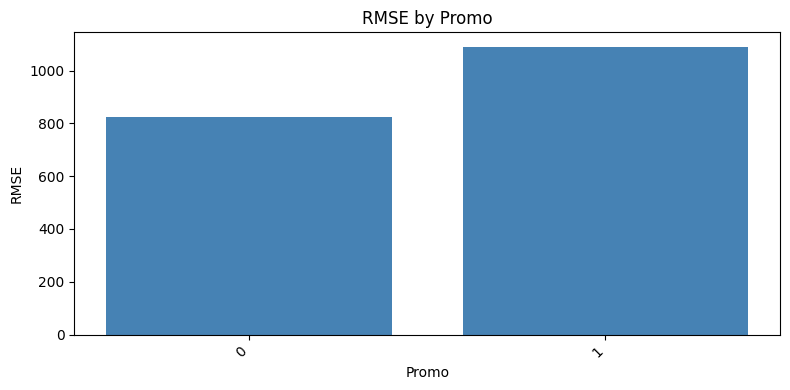

=== StoreType ===


,n,MAE,RMSE,MAPE,RMSPE,bias,underprediction_share,segment,segment_value
0,94310,631.420583,933.514408,0.091330,0.145719,-258.795978,0.625024,StoreType,a
1,3213,936.787466,1446.100116,0.086318,0.117624,-300.594372,0.584189,StoreType,b
2,23125,679.463645,1020.838058,0.095461,0.151917,-261.504679,0.613708,StoreType,c
3,54436,659.143564,926.625162,0.092033,0.128203,-234.625213,0.601495,StoreType,d


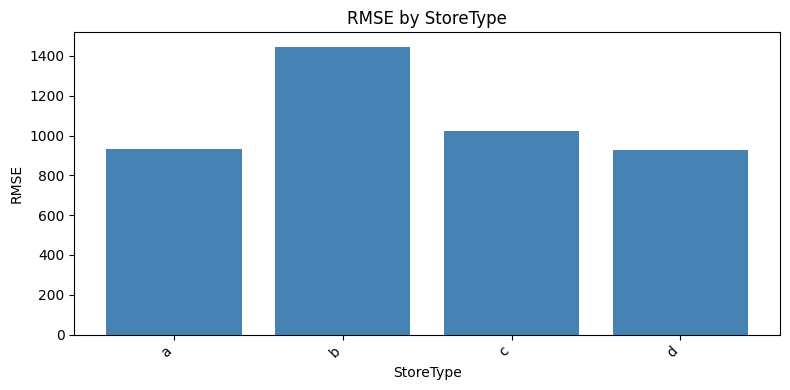

=== dayofweek ===


,n,MAE,RMSE,MAPE,RMSPE,bias,underprediction_share,segment,segment_value
0,27886,808.925051,1159.363294,0.100988,0.166941,-367.283699,0.656817,dayofweek,0
1,30077,650.844711,920.422396,0.089206,0.122017,-286.495205,0.639425,dayofweek,1
2,30073,673.063383,996.279971,0.093744,0.126743,-298.393979,0.622053,dayofweek,2
3,28310,647.305708,970.661594,0.092064,0.140785,-237.470937,0.616213,dayofweek,3
4,27889,579.294810,829.455324,0.080591,0.107493,-189.981963,0.606547,dayofweek,4
5,30083,551.298154,807.350781,0.093930,0.167158,-132.132436,0.553037,dayofweek,5
6,766,930.618480,1382.031446,0.143768,0.238138,-474.505670,0.659269,dayofweek,6


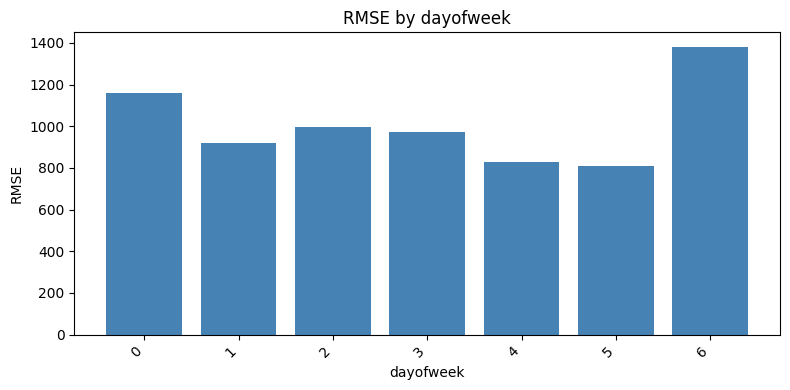

=== sales_quantile ===


,n,MAE,RMSE,MAPE,RMSPE,bias,underprediction_share,segment,segment_value
0,35038,376.469404,580.602485,0.106511,0.216337,116.479898,0.431703,sales_quantile,Q1 (low)
1,35019,450.166129,597.875721,0.084064,0.111761,-47.547296,0.563865,sales_quantile,Q2
2,35002,556.106275,720.563170,0.084545,0.109493,-178.996328,0.637678,sales_quantile,Q3
3,35015,701.594212,902.702006,0.086617,0.111267,-328.788108,0.682393,sales_quantile,Q4
4,35010,1175.854136,1591.803428,0.098266,0.124785,-823.497031,0.761839,sales_quantile,Q5 (high)


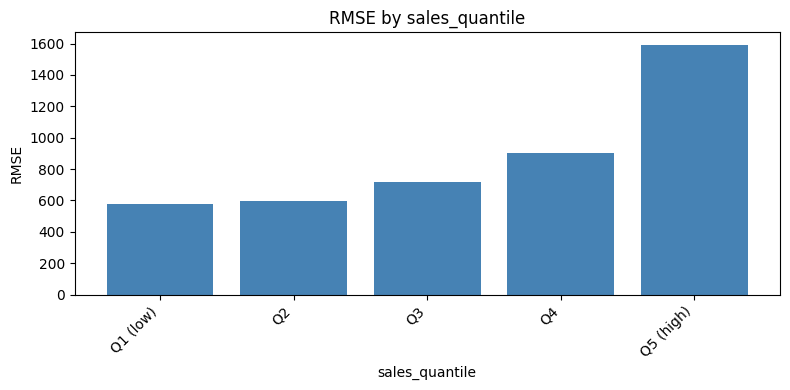

=== is_state_holiday ===


,n,MAE,RMSE,MAPE,RMSPE,bias,underprediction_share,segment,segment_value
0,174863,649.974995,948.758790,0.091748,0.139958,-250.693644,0.615310,is_state_holiday,0
1,221,2245.844359,3256.095959,0.293510,0.476547,-1607.101940,0.737557,is_state_holiday,1


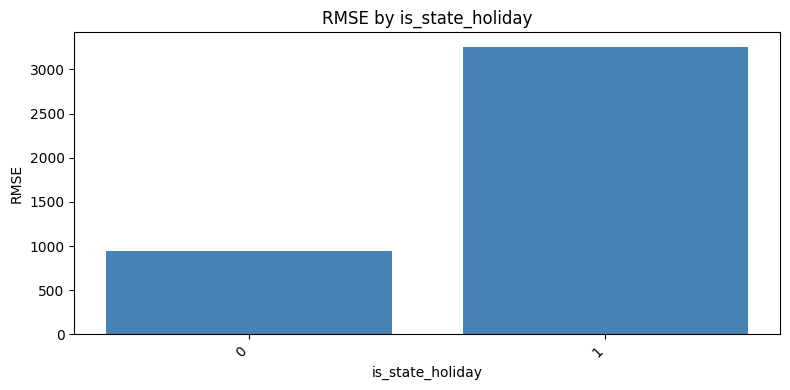

=== SchoolHoliday ===


,n,MAE,RMSE,MAPE,RMSPE,bias,underprediction_share,segment,segment_value
0,146618,623.318553,906.008290,0.090350,0.141775,-237.572724,0.617619,SchoolHoliday,0
1,28466,799.662388,1176.380738,0.100514,0.136243,-328.805404,0.604370,SchoolHoliday,1


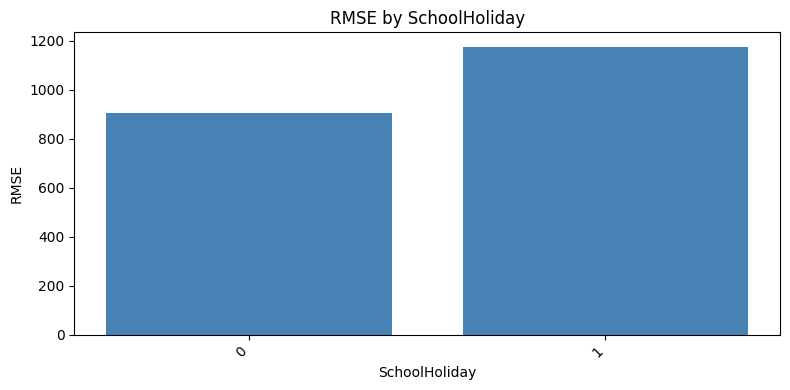

=== StateHoliday ===


,n,MAE,RMSE,MAPE,RMSPE,bias,underprediction_share,segment,segment_value
0,174863,649.974995,948.758790,0.091748,0.139958,-250.693644,0.615310,StateHoliday,0
1,172,2167.911978,3162.525654,0.291333,0.499795,-1599.626962,0.755814,StateHoliday,a
2,49,2519.402921,3565.159567,0.301154,0.383955,-1633.340638,0.673469,StateHoliday,b


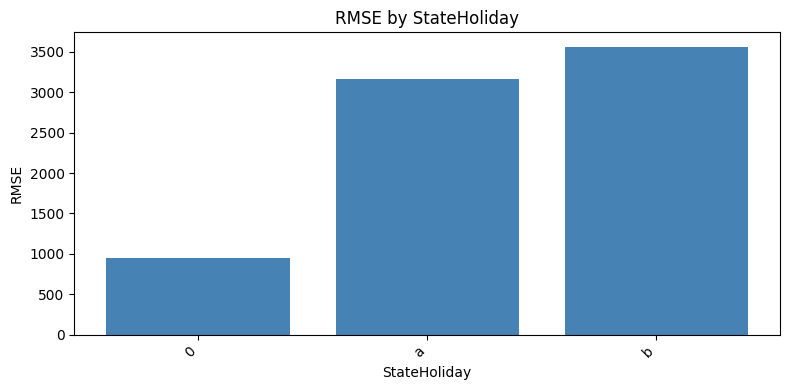

=== is_month_end ===


,n,MAE,RMSE,MAPE,RMSPE,bias,underprediction_share,segment,segment_value
0,168367,641.947989,941.957134,0.091560,0.136023,-240.503408,0.612157,is_month_end,False
1,6717,903.684986,1241.652648,0.103086,0.231587,-550.748103,0.698377,is_month_end,True


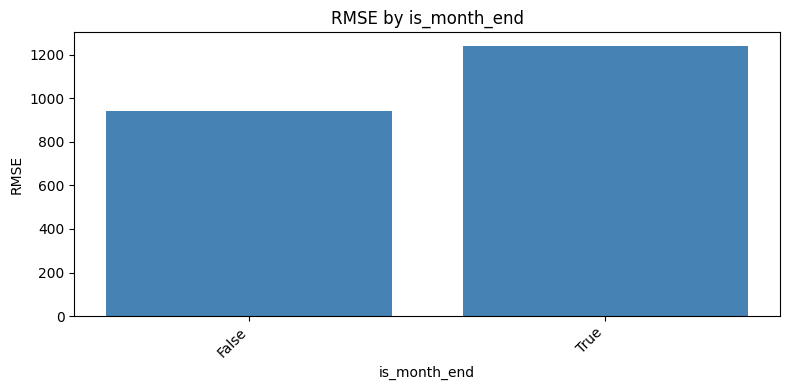

=== is_weekend ===


,n,MAE,RMSE,MAPE,RMSPE,bias,underprediction_share,segment,segment_value
0,144235,671.510750,980.530113,0.091325,0.134040,-276.311581,0.628253,is_weekend,False
1,30849,560.716915,826.472668,0.095168,0.169281,-140.633778,0.555674,is_weekend,True


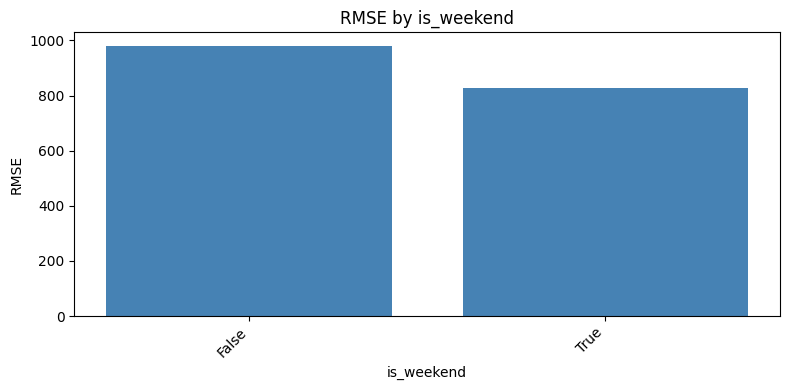

,n,MAE,RMSE,MAPE,RMSPE,bias,underprediction_share,segment,segment_value
0,94448,556.069065,822.408309,0.092524,0.142686,-184.204661,0.593544,Promo,0
1,80636,764.339725,1090.345684,0.091392,0.138758,-332.288933,0.641140,Promo,1
2,94310,631.420583,933.514408,0.091330,0.145719,-258.795978,0.625024,StoreType,a
3,3213,936.787466,1446.100116,0.086318,0.117624,-300.594372,0.584189,StoreType,b
4,23125,679.463645,1020.838058,0.095461,0.151917,-261.504679,0.613708,StoreType,c
5,54436,659.143564,926.625162,0.092033,0.128203,-234.625213,0.601495,StoreType,d
6,27886,808.925051,1159.363294,0.100988,0.166941,-367.283699,0.656817,dayofweek,0
7,30077,650.844711,920.422396,0.089206,0.122017,-286.495205,0.639425,dayofweek,1
8,30073,673.063383,996.279971,0.093744,0.126743,-298.393979,0.622053,dayofweek,2
9,28310,647.305708,970.661594,0.092064,0.140785,-237.470937,0.616213,dayofweek,3


In [8]:
segment_cols = [
    "Promo",
    "StoreType",
    "dayofweek",
    "sales_quantile",
    "is_state_holiday",
    "SchoolHoliday",
    "StateHoliday",
    "is_month_end",
    "is_weekend",
]

segment_reports = {}
for col in segment_cols:
    report = error_analysis_by_segment(errors_df, col)
    segment_reports[col] = report
    print(f"=== {col} ===")
    display(report)

    plot_df = report.sort_values("segment_value")
    plt.figure(figsize=(8, 4))
    plt.bar(plot_df["segment_value"].astype(str), plot_df["RMSE"], color="steelblue")
    plt.title(f"RMSE by {col}")
    plt.xlabel(col)
    plt.ylabel("RMSE")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

segment_summary = pd.concat(segment_reports.values(), ignore_index=True)
segment_summary

## Вывод для baseline
Сегментный анализ ошибок показал, что модель занижает продажи, особенно в периоды промо-акций, на высоких уровнях спроса, в праздничные дни и в конце месяца. Это указывает на недостаточную информативность признакового пространства для сложных ситуаций со спросом. Поэтому далее воспользуемся методом feature engineering.

# Feature engineering

- В качестве основного направления улучшения модели решил использовать feature engineering, так как сегментный анализ показал, что проблема связана не столько с архитектурой, сколько с недостаточной информативностью признаков в сложных режимах спроса.

- Для этого добавим признаки, отражающие динамику промо-акций, календарные эффекты и локальную историю спроса.


In [9]:
reader = DataReader()
raw_data = reader.read()

split = TemporalSpliter(train_ratio=0.8, val_ratio=0.2).split(raw_data["train"])
train_raw = split.train
val_raw = split.val

improved_preprocessor = PreprocessingModule(use_log=True)
improved_preprocessor.fit(train_raw, raw_data["store"])

train_improved_df = improved_preprocessor.transform(train_raw)
val_improved_df = improved_preprocessor.transform(val_raw)

improved_features = improved_preprocessor.feature_columns_
X_train_improved = train_improved_df[improved_features]
y_train_improved = train_improved_df["y"]
X_val_improved = val_improved_df[improved_features]
y_val_improved = val_improved_df["y"]

PROMO_CALENDAR_FEATURES = [
    "promo_streak",
    "promo_start_flag",
    "days_since_last_promo",
    "days_to_month_end",
    "is_day_before_holiday",
    "promo_x_dayofweek",
]

HISTORY_EXTENSION_FEATURES = [
    "rolling_max_7",
    "rolling_max_28",
    "trend_7_28",
    "lag_7_to_rolling_mean_28",
    "rolling_max_7_is_missing",
    "rolling_max_28_is_missing",
]

baseline_features = [
    col
    for col in improved_features
    if col not in PROMO_CALENDAR_FEATURES + HISTORY_EXTENSION_FEATURES
]

print("Baseline features:", len(baseline_features))
print("Promo/calendar features:", len(PROMO_CALENDAR_FEATURES))
print("History extension features:", len(HISTORY_EXTENSION_FEATURES))
print("All features:", len(improved_features))


Baseline features: 49
Promo/calendar features: 6
History extension features: 6
All features: 61


In [10]:
def train_and_evaluate(feature_cols, model_name):
    model = HistGradientBoostingRegressor(
        loss="squared_error",
        random_state=42,
        **BEST_PARAMS,
    )
    model.fit(X_train_improved[feature_cols], y_train_improved)
    val_pred_subset = model.predict(X_val_improved[feature_cols])
    return evaluate_model(model_name, y_val_improved, val_pred_subset)


### Promo/calendar features only


Добавленные promo/calendar признаки:

- promo_streak — длительность текущего промо-периода;
- promo_start_flag — флаг начала промо;
- days_since_last_promo — сколько дней прошло с последнего промо;
- days_to_month_end — сколько дней осталось до конца месяца;
- is_day_before_holiday — флаг дня перед праздником;
- promo_x_dayofweek — взаимодействие промо и дня недели.


In [11]:
metrics_promo_only = train_and_evaluate(
    baseline_features + PROMO_CALENDAR_FEATURES,
    "baseline + promo/calendar",
)
metrics_promo_only


{'model': 'baseline + promo/calendar',
 'MAE': 644.2018428102741,
 'RMSE': np.float64(941.7192688604022),
 'RMSPE': np.float64(0.14009893188517208),
 'R2': 0.9050160536918959}

Видим по результатам, что все метрики улучшились по сравнению с baseline.

### History extension features only


Добавленные history extensions признаки:

- rolling_max_7 — максимум продаж за последние 7 дней;
- rolling_max_28 — максимум продаж за последние 28 дней;
- trend_7_28 — соотношение краткосрочного и долгосрочного среднего спроса;
- lag_7_to_rolling_mean_28 — отношение продаж неделю назад к среднему за 28 дней.

Пока прогоним здесь только новые "history" признаки.

In [12]:
metrics_history_only = train_and_evaluate(
    baseline_features + HISTORY_EXTENSION_FEATURES,
    "baseline + history extensions",
)
metrics_history_only


{'model': 'baseline + history extensions',
 'MAE': 638.9543164317902,
 'RMSE': np.float64(935.05866048369),
 'RMSPE': np.float64(0.14018746740347926),
 'R2': 0.9063549103496316}

Видим, что ошибка уменьшилась больше, чем при новых calendar признаках.

### Все новые признаки вместе


Учитывая то, что все новые признаки дали прирост, то попробуем использовать все их.

In [13]:
metrics_full = train_and_evaluate(
    improved_features,
    "baseline + promo/calendar + history",
)
metrics_full


{'model': 'baseline + promo/calendar + history',
 'MAE': 638.7817566224043,
 'RMSE': np.float64(930.6083387214436),
 'RMSPE': np.float64(0.139700624432173),
 'R2': 0.9072441787032448}

Произошел лучший прирост по метрикам качества! 

## Вывод по feature engineering

In [14]:
with (MODELS_DIR / "hgb_baseline_metrics.json").open(encoding="utf-8") as f:
    metrics_baseline_saved = json.load(f)

ablation_results = pd.DataFrame(
    [
        metrics_baseline_saved,
        metrics_promo_only,
        metrics_history_only,
        metrics_full,
    ]
).set_index("model")

display(ablation_results)

full_model = HistGradientBoostingRegressor(
    loss="squared_error",
    random_state=42,
    **BEST_PARAMS,
)
full_model.fit(X_train_improved, y_train_improved)

full_model_path = MODELS_DIR / "hgb_full.joblib"
full_metrics_path = MODELS_DIR / "hgb_full_metrics.json"
joblib.dump(full_model, full_model_path)

metrics_full_serializable = {
    key: float(value) if isinstance(value, (np.floating, float)) else value
    for key, value in metrics_full.items()
}
with full_metrics_path.open("w", encoding="utf-8") as f:
    json.dump(metrics_full_serializable, f, indent=2)

print(f"Full model saved to: {full_model_path}")
print(f"Full metrics saved to: {full_metrics_path}")


,MAE,RMSE,RMSPE,R2
model,,,,
HistGradientBoosting tuned,651.989383,955.190885,0.140890,0.902279
baseline + promo/calendar,644.201843,941.719269,0.140099,0.905016
baseline + history extensions,638.954316,935.058660,0.140187,0.906355
baseline + promo/calendar + history,638.781757,930.608339,0.139701,0.907244


Full model saved to: /Users/roman/Desktop/ITMO/MLOps/final_project/ID_forecasting_assistant/models/hgb_full.joblib
Full metrics saved to: /Users/roman/Desktop/ITMO/MLOps/final_project/ID_forecasting_assistant/models/hgb_full_metrics.json


- Добавление новых признаков улучшило качество модели по всем основным метрикам.
- Наилучший результат показала модель baseline + promo/calendar + history:
    - MAE = 638.78
    - RMSE = 930.61
    - RMSPE = 0.13970
    - R² = 0.90724
- По сравнению с исходной HistGradientBoosting tuned модель стала точнее, особенно по MAE и RMSE.
- Признаки из блока history extensions дали больший вклад, чем только promo/calendar признаки.
- Совместное использование promo/calendar и history признаков дало лучший итоговый результат, что подтверждает полезность расширенного feature engineering.

# Сегментный анализ после добавление новых признаков

Повторяем сегментный разбор для модели `baseline + promo/calendar + history` и на гистограммах сравниваем RMSE по сегментам с исходным baseline.

In [15]:
def build_errors_df(y_true_log, y_pred_log, X_features):
    df = pd.DataFrame(
        {
            "y_true": np.expm1(y_true_log),
            "y_pred": np.clip(np.expm1(y_pred_log), 0, None),
        }
    )
    df = df.join(X_features[segment_feature_cols])

    store_type_map = {
        "StoreType_a": "a",
        "StoreType_b": "b",
        "StoreType_c": "c",
        "StoreType_d": "d",
    }
    df["StoreType"] = (
        df[["StoreType_a", "StoreType_b", "StoreType_c", "StoreType_d"]]
        .idxmax(axis=1)
        .map(store_type_map)
    )

    holiday_map = {
        "StateHoliday_a": "a",
        "StateHoliday_b": "b",
        "StateHoliday_c": "c",
    }
    df["StateHoliday"] = "0"
    state_holiday_mask = df["is_state_holiday"] == 1
    df.loc[state_holiday_mask, "StateHoliday"] = (
        df.loc[state_holiday_mask, ["StateHoliday_a", "StateHoliday_b", "StateHoliday_c"]]
        .idxmax(axis=1)
        .map(holiday_map)
    )

    df["sales_quantile"] = pd.qcut(
        df["y_true"],
        q=5,
        labels=["Q1 (low)", "Q2", "Q3", "Q4", "Q5 (high)"],
        duplicates="drop",
    )
    return df


full_val_pred = full_model.predict(X_val_improved)
errors_df_full = build_errors_df(y_val_improved, full_val_pred, X_val_improved)
errors_df_full.head()

,y_true,y_pred,Promo,dayofweek,is_weekend,is_month_end,SchoolHoliday,is_state_holiday,StoreType_a,StoreType_b,StoreType_c,StoreType_d,StateHoliday_a,StateHoliday_b,StateHoliday_c,StoreType,StateHoliday,sales_quantile
0,4840.0,4434.991659,0,5,True,False,0,0,0,0,1,0,0,0,0,c,0,Q2
1,4781.0,5588.598562,1,0,False,False,0,0,0,0,1,0,0,0,0,c,0,Q2
2,4806.0,4815.103366,1,1,False,False,0,0,0,0,1,0,0,0,0,c,0,Q2
3,4310.0,4591.696981,1,2,False,False,0,0,0,0,1,0,0,0,0,c,0,Q1 (low)
4,5171.0,4388.269388,1,3,False,False,0,0,0,0,1,0,0,0,0,c,0,Q2


=== Promo (baseline + promo/calendar + history) ===


,n,MAE,RMSE,MAPE,RMSPE,bias,underprediction_share,segment,segment_value
0,94448,541.827240,793.070462,0.090940,0.140769,-158.529870,0.585317,Promo,0
1,80636,752.343444,1069.444015,0.090552,0.138439,-317.815743,0.639925,Promo,1


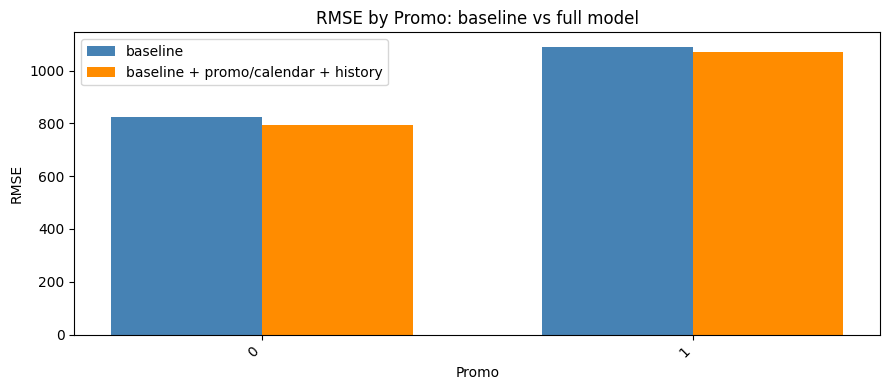

=== StoreType (baseline + promo/calendar + history) ===


,n,MAE,RMSE,MAPE,RMSPE,bias,underprediction_share,segment,segment_value
0,94310,613.836019,907.065122,0.089604,0.144368,-228.853078,0.613753,StoreType,a
1,3213,918.453574,1382.520154,0.085879,0.117020,-269.655072,0.565826,StoreType,b
2,23125,670.140388,999.912047,0.094664,0.151163,-240.818746,0.610724,StoreType,c
3,54436,652.171399,906.891614,0.091396,0.127071,-231.129223,0.607300,StoreType,d


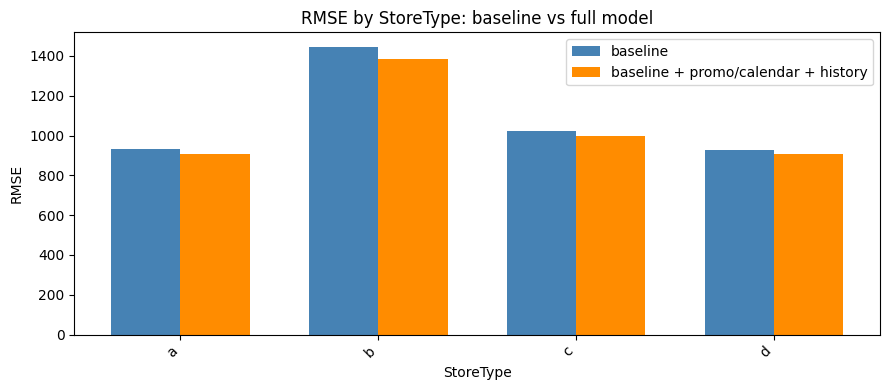

=== dayofweek (baseline + promo/calendar + history) ===


,n,MAE,RMSE,MAPE,RMSPE,bias,underprediction_share,segment,segment_value
0,27886,808.936123,1160.019630,0.101028,0.168075,-385.227834,0.663451,dayofweek,0
1,30077,648.865512,910.297081,0.088976,0.121255,-288.127487,0.654221,dayofweek,1
2,30073,626.072733,913.785009,0.088345,0.118920,-232.877143,0.612942,dayofweek,2
3,28310,609.829494,913.183548,0.087509,0.137193,-214.180746,0.605440,dayofweek,3
4,27889,568.272062,820.853563,0.079306,0.106447,-166.355972,0.585356,dayofweek,4
5,30083,570.544079,825.857103,0.097840,0.170364,-106.408937,0.542366,dayofweek,5
6,766,864.450454,1226.512629,0.141143,0.227736,-371.243684,0.640992,dayofweek,6


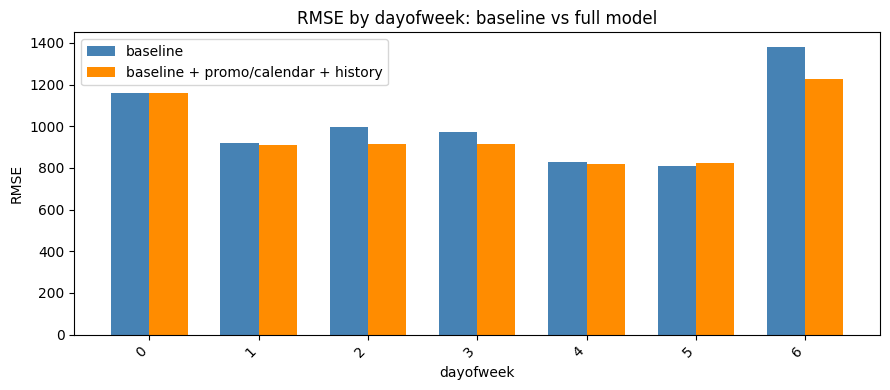

=== sales_quantile (baseline + promo/calendar + history) ===


,n,MAE,RMSE,MAPE,RMSPE,bias,underprediction_share,segment,segment_value
0,35038,376.006755,582.627364,0.106349,0.216812,114.111330,0.434157,sales_quantile,Q1 (low)
1,35019,451.249010,597.757922,0.084249,0.111641,-44.300067,0.566178,sales_quantile,Q2
2,35002,553.720798,714.929617,0.084202,0.108612,-164.152600,0.630593,sales_quantile,Q3
3,35015,686.831236,884.916207,0.084840,0.109163,-293.296553,0.666257,sales_quantile,Q4
4,35010,1126.333053,1529.598587,0.094155,0.119910,-772.112542,0.755298,sales_quantile,Q5 (high)


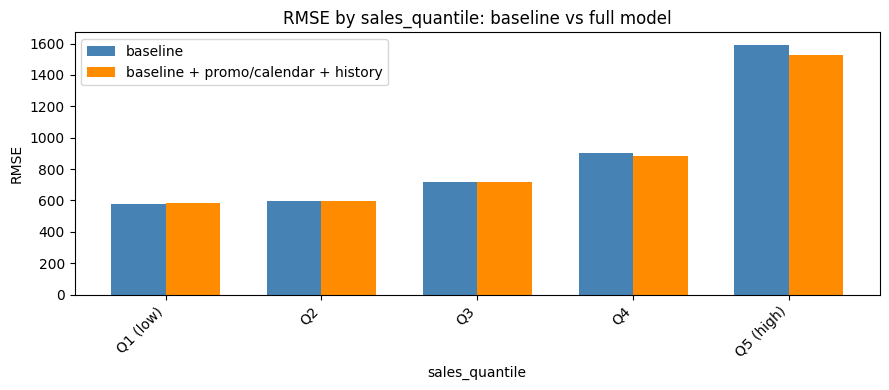

=== is_state_holiday (baseline + promo/calendar + history) ===


,n,MAE,RMSE,MAPE,RMSPE,bias,underprediction_share,segment,segment_value
0,174863,636.884937,924.800686,0.090528,0.138836,-230.265252,0.610283,is_state_holiday,0
1,221,2139.612713,3064.644311,0.274846,0.458299,-1517.405539,0.755656,is_state_holiday,1


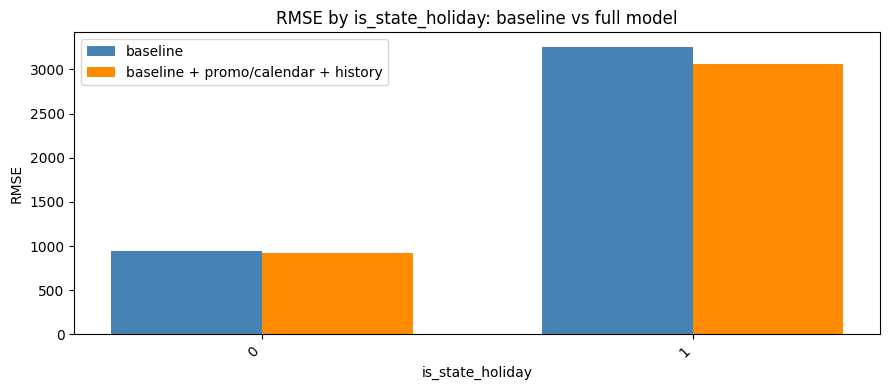

=== SchoolHoliday (baseline + promo/calendar + history) ===


,n,MAE,RMSE,MAPE,RMSPE,bias,underprediction_share,segment,segment_value
0,146618,612.410573,886.191924,0.089387,0.141142,-218.874257,0.613192,SchoolHoliday,0
1,28466,774.610118,1132.107026,0.097839,0.132026,-298.929023,0.596431,SchoolHoliday,1


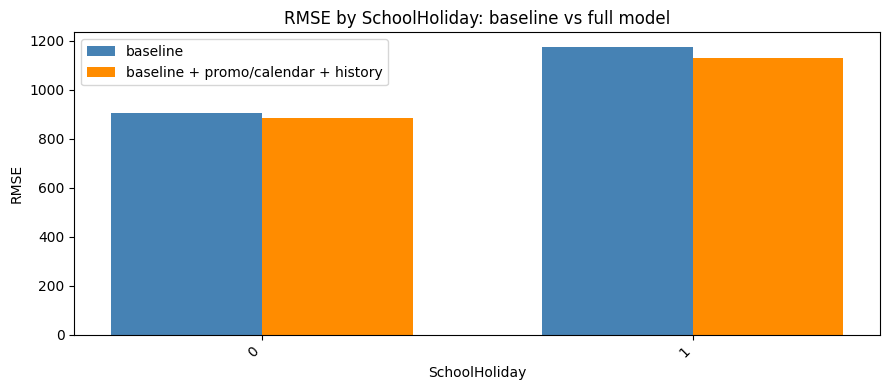

=== StateHoliday (baseline + promo/calendar + history) ===


,n,MAE,RMSE,MAPE,RMSPE,bias,underprediction_share,segment,segment_value
0,174863,636.884937,924.800686,0.090528,0.138836,-230.265252,0.610283,StateHoliday,0
1,172,2086.471494,2999.078380,0.281724,0.491853,-1472.644589,0.761628,StateHoliday,a
2,49,2326.149237,3284.449621,0.250706,0.313254,-1674.525608,0.734694,StateHoliday,b


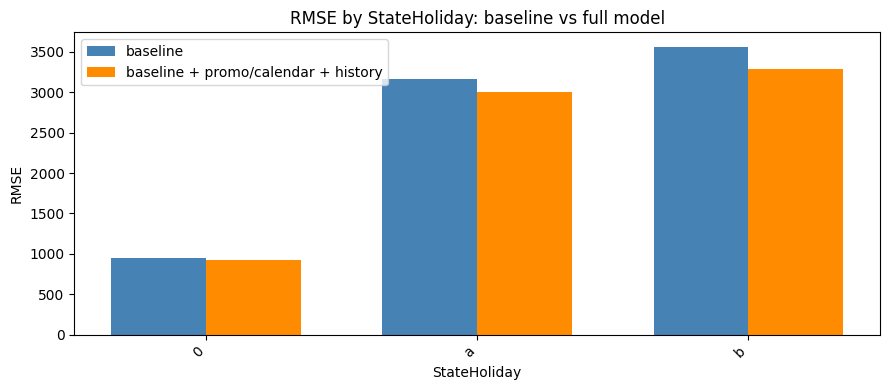

=== is_month_end (baseline + promo/calendar + history) ===


,n,MAE,RMSE,MAPE,RMSPE,bias,underprediction_share,segment,segment_value
0,168367,630.221114,920.190019,0.090404,0.135146,-224.835451,0.608718,is_month_end,False
1,6717,853.361141,1161.617814,0.099708,0.225603,-408.716560,0.654310,is_month_end,True


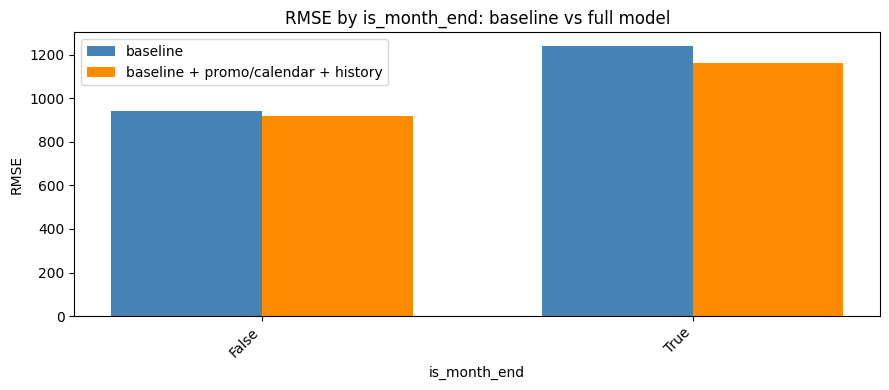

=== is_weekend (baseline + promo/calendar + history) ===


,n,MAE,RMSE,MAPE,RMSPE,bias,underprediction_share,segment,segment_value
0,144235,651.815568,949.219195,0.089017,0.131763,-257.321362,0.624509,is_weekend,False
1,30849,577.841958,838.127682,0.098916,0.172021,-112.984950,0.544815,is_weekend,True


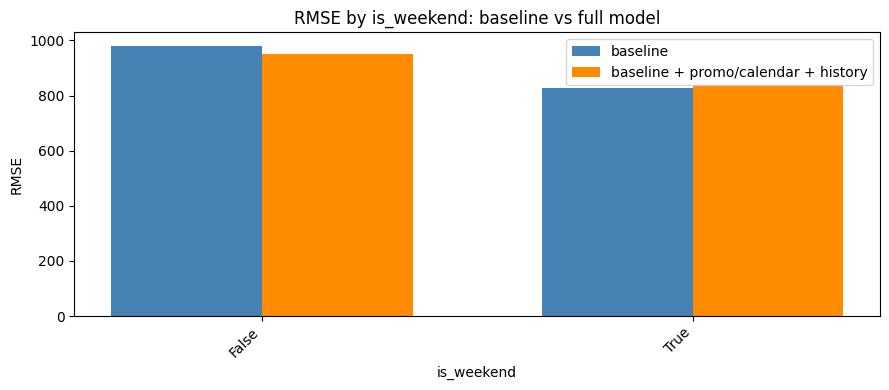

,n,MAE,RMSE,MAPE,RMSPE,bias,underprediction_share,segment,segment_value
0,94448,541.827240,793.070462,0.090940,0.140769,-158.529870,0.585317,Promo,0
1,80636,752.343444,1069.444015,0.090552,0.138439,-317.815743,0.639925,Promo,1
2,94310,613.836019,907.065122,0.089604,0.144368,-228.853078,0.613753,StoreType,a
3,3213,918.453574,1382.520154,0.085879,0.117020,-269.655072,0.565826,StoreType,b
4,23125,670.140388,999.912047,0.094664,0.151163,-240.818746,0.610724,StoreType,c
5,54436,652.171399,906.891614,0.091396,0.127071,-231.129223,0.607300,StoreType,d
6,27886,808.936123,1160.019630,0.101028,0.168075,-385.227834,0.663451,dayofweek,0
7,30077,648.865512,910.297081,0.088976,0.121255,-288.127487,0.654221,dayofweek,1
8,30073,626.072733,913.785009,0.088345,0.118920,-232.877143,0.612942,dayofweek,2
9,28310,609.829494,913.183548,0.087509,0.137193,-214.180746,0.605440,dayofweek,3


In [16]:
segment_reports_full = {}

for col in segment_cols:
    report_full = error_analysis_by_segment(errors_df_full, col)
    segment_reports_full[col] = report_full
    print(f"=== {col} (baseline + promo/calendar + history) ===")
    display(report_full)

    baseline_report = segment_reports[col][["segment_value", "RMSE"]].rename(
        columns={"RMSE": "RMSE_baseline"}
    )
    full_report = report_full[["segment_value", "RMSE"]].rename(
        columns={"RMSE": "RMSE_full"}
    )
    compare_df = baseline_report.merge(full_report, on="segment_value", how="outer")
    compare_df = compare_df.sort_values("segment_value")

    x = np.arange(len(compare_df))
    width = 0.35

    plt.figure(figsize=(9, 4))
    plt.bar(
        x - width / 2,
        compare_df["RMSE_baseline"],
        width,
        label="baseline",
        color="steelblue",
    )
    plt.bar(
        x + width / 2,
        compare_df["RMSE_full"],
        width,
        label="baseline + promo/calendar + history",
        color="darkorange",
    )
    plt.title(f"RMSE by {col}: baseline vs full model")
    plt.xlabel(col)
    plt.ylabel("RMSE")
    plt.xticks(x, compare_df["segment_value"].astype(str), rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()

segment_summary_full = pd.concat(segment_reports_full.values(), ignore_index=True)
segment_summary_full

## Общий вывод по анализу

- После добавления новых признаков качество модели улучшилось практически во всех основных сегментах.
- Снизились ошибки в промо-периоды (Promo=1), в конце месяца (is_month_end=True), в дни школьных каникул и в большинстве дней недели.
- Улучшение особенно заметно в сегментах с высокими продажами: для Q5 (high) уменьшились MAE, RMSE и MAPE, то есть модель стала лучше обрабатывать пики спроса.
- Также улучшились результаты в праздничные дни (StateHoliday), хотя эти сегменты по-прежнему остаются самыми сложными.
- По большинству сегментов уменьшился отрицательный bias, что означает снижение систематического занижения прогноза.
- Однако проблема полностью не исчезла: модель всё ещё недооценивает продажи в сложных режимах спроса, особенно в промо-периоды, праздничные дни, в конце месяца и на самых высоких уровнях продаж. Поэтому следующим шагом попробуем postprocessing для коррекции.

# Postprocessing

* После обучения полной модели применяется **простая postprocessing-коррекция** предсказаний в шкале продаж.
* Коррекция сделана в виде небольшого **uplift** для сегментов, где по анализу ошибок сохранялось систематическое недопредсказание.
* Используются следующие правила:

  * `Promo=1` → **+2%**
  * `is_month_end=1` → **+2%**
  * `is_state_holiday=1` → **+4%**
  * `high-demand regime` → **+2%**
* Для high-demand режима используется **proxy-признак**, чтобы не опираться на истинные продажи:

  * `trend_7_28 > 1.15`
  * или `lag_7_to_rolling_mean_28 > 1.15`
  * или `rolling_max_7 / rolling_mean_28 > 1.30`
* Если выполняется несколько условий, uplift суммируется, но общий рост прогноза ограничивается **cap +5%**.
* Такой подход выбран, потому что он:

  * напрямую исправляет выявленный отрицательный `bias`;
  * не требует изменения архитектуры модели;
  * особенно полезен в редких, но важных режимах спроса: промо, конец месяца, праздники и локальные пики продаж.


In [17]:
UPLIFT_CONFIG = DEFAULT_SALES_UPLIFT_CONFIG

full_val_pred_pp, uplift_fraction = apply_sales_uplift_to_log_predictions(
    full_val_pred,
    val_improved_df,
    UPLIFT_CONFIG,
)

metrics_full_pp = evaluate_model(
    "baseline + promo/calendar + history + postprocessing",
    y_val_improved,
    full_val_pred_pp,
)

postprocess_results = pd.DataFrame([metrics_full, metrics_full_pp]).set_index("model")
display(postprocess_results)

uplift_summary = pd.Series(
    {
        "share_with_uplift": (uplift_fraction > 0).mean(),
        "mean_uplift": uplift_fraction.mean(),
        "max_uplift": uplift_fraction.max(),
        "share_high_demand_regime": high_demand_mask(val_improved_df, UPLIFT_CONFIG).mean(),
    },
    name="value",
)
display(uplift_summary.to_frame())

metrics_full_pp

,MAE,RMSE,RMSPE,R2
model,,,,
baseline + promo/calendar + history,638.781757,930.608339,0.139701,0.907244
baseline + promo/calendar + history + postprocessing,622.426859,905.552668,0.142107,0.912172


,value
share_with_uplift,0.775079
mean_uplift,0.021672
max_uplift,0.050000
share_high_demand_regime,0.592853


{'model': 'baseline + promo/calendar + history + postprocessing',
 'MAE': 622.4268590277601,
 'RMSE': np.float64(905.5526681213896),
 'RMSPE': np.float64(0.14210736988874484),
 'R2': 0.9121716498170154}

* Добавление **postprocessing** дало заметное улучшение по основным абсолютным метрикам.
* По сравнению с моделью `baseline + promo/calendar + history`:

  * `MAE` снизился с **638.78** до **622.43**
  * `RMSE` снизился с **930.61** до **905.55**
  * `R²` вырос с **0.9072** до **0.9122**

* При этом `RMSPE` немного ухудшился: с **0.13970** до **0.14211**, то есть относительная ошибка на части наблюдений выросла.
* Uplift был применён примерно к **77.5%** наблюдений, при среднем uplift около **2.17%** и максимальном ограничении **+5%**.
* Высокий режим спроса был зафиксирован примерно у **59.3%** наблюдений, поэтому postprocessing повлиял на значительную часть выборки.
* В целом postprocessing оказался полезным: он улучшил `MAE`, `RMSE` и `R²`, то есть сделал прогноз точнее в абсолютном выражении, несмотря на небольшое ухудшение `RMSPE`.


## Анализ bias и RMSE после postprocessing

=== Promo: full model vs postprocessing ===


,segment_value,RMSE_full,bias_full,RMSE_pp,bias_pp
0,0,793.070462,-158.529870,782.345265,-89.196657
1,1,1069.444015,-317.815743,1031.313978,-52.408946


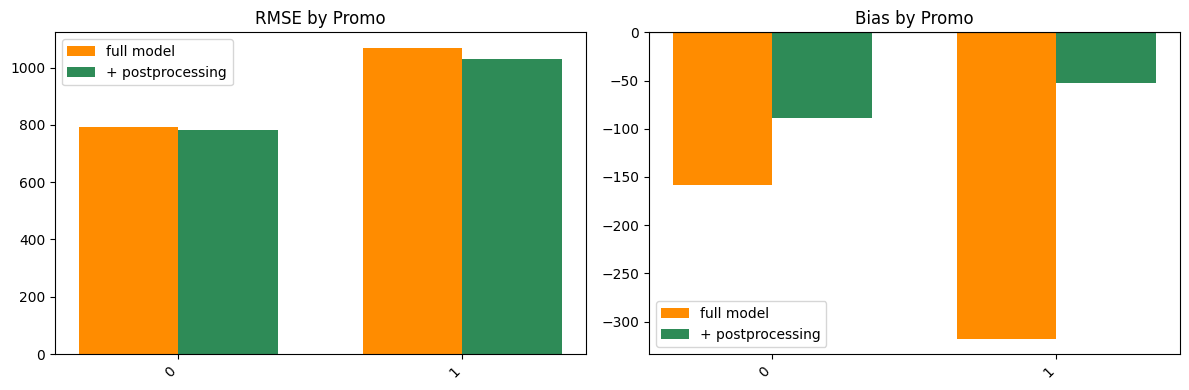

=== is_month_end: full model vs postprocessing ===


,segment_value,RMSE_full,bias_full,RMSE_pp,bias_pp
0,False,920.190019,-224.835451,896.570914,-73.001878
1,True,1161.617814,-408.716560,1107.134367,-53.504015


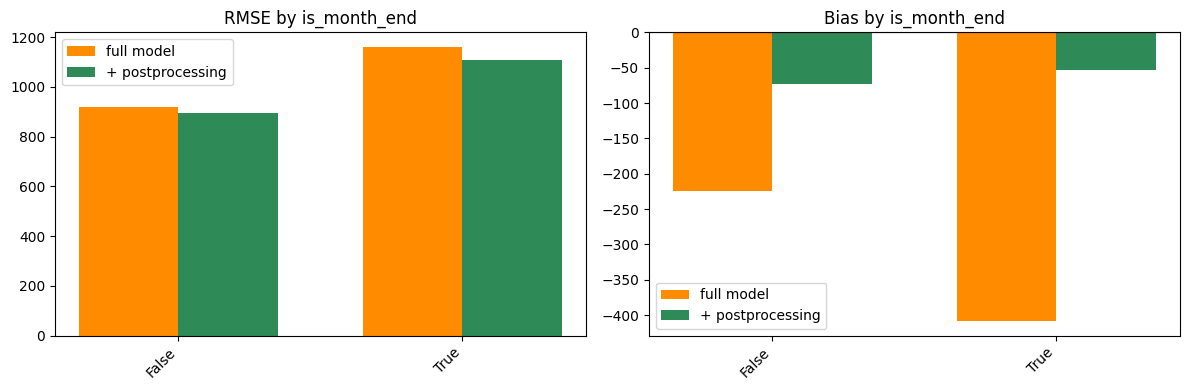

=== is_state_holiday: full model vs postprocessing ===


,segment_value,RMSE_full,bias_full,RMSE_pp,bias_pp
0,0,924.800686,-230.265252,900.648395,-70.924701
1,1,3064.644311,-1517.405539,2798.011659,-1123.926097


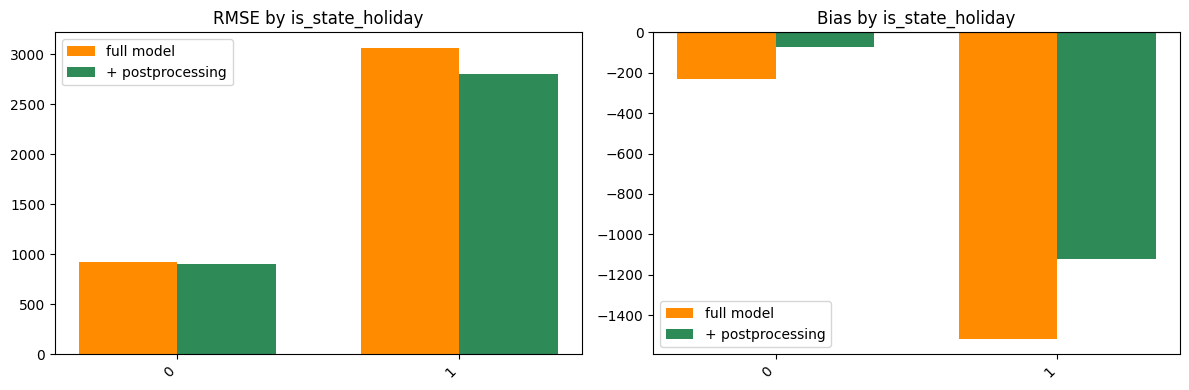

=== sales_quantile: full model vs postprocessing ===


,segment_value,RMSE_full,bias_full,RMSE_pp,bias_pp
0,Q1 (low),582.627364,114.111330,611.432351,176.116142
1,Q2,597.757922,-44.300067,620.823620,57.325358
2,Q3,714.929617,-164.152600,725.195239,-23.182975
3,Q4,884.916207,-293.296553,876.130074,-95.281774
4,Q5 (high),1529.598587,-772.112542,1430.997375,-476.463466


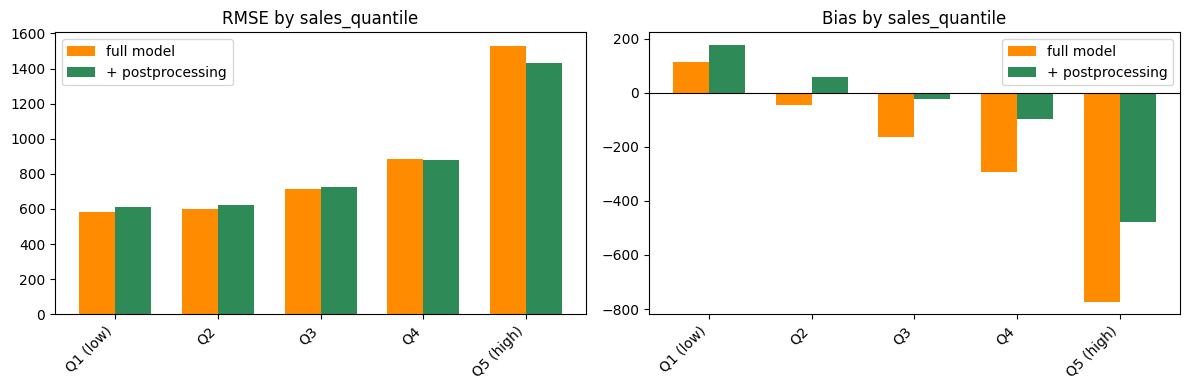

In [18]:
errors_df_full_pp = build_errors_df(
    y_val_improved,
    full_val_pred_pp,
    X_val_improved,
)

focus_segments = ["Promo", "is_month_end", "is_state_holiday", "sales_quantile"]

for col in focus_segments:
    report_pp = error_analysis_by_segment(errors_df_full_pp, col)
    report_full = segment_reports_full[col][["segment_value", "RMSE", "bias"]].rename(
        columns={"RMSE": "RMSE_full", "bias": "bias_full"}
    )
    report_pp = report_pp[["segment_value", "RMSE", "bias"]].rename(
        columns={"RMSE": "RMSE_pp", "bias": "bias_pp"}
    )
    compare_df = report_full.merge(report_pp, on="segment_value", how="outer").sort_values(
        "segment_value"
    )

    print(f"=== {col}: full model vs postprocessing ===")
    display(compare_df)

    x = np.arange(len(compare_df))
    width = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(x - width / 2, compare_df["RMSE_full"], width, label="full model", color="darkorange")
    axes[0].bar(x + width / 2, compare_df["RMSE_pp"], width, label="+ postprocessing", color="seagreen")
    axes[0].set_title(f"RMSE by {col}")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(compare_df["segment_value"].astype(str), rotation=45, ha="right")
    axes[0].legend()

    axes[1].bar(x - width / 2, compare_df["bias_full"], width, label="full model", color="darkorange")
    axes[1].bar(x + width / 2, compare_df["bias_pp"], width, label="+ postprocessing", color="seagreen")
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_title(f"Bias by {col}")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(compare_df["segment_value"].astype(str), rotation=45, ha="right")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

* **Promo-сегменты:** postprocessing улучшил результат в обоих сегментах.
  Для `Promo=0` и `Promo=1` снизился `RMSE`, а отрицательный `bias` стал заметно меньше. Особенно сильный эффект виден на `Promo=1`: bias улучшился с **-317.8** до **-52.4**.

* **Конец месяца:** в сегментах `is_month_end=False` и `is_month_end=True` postprocessing также снизил `RMSE` и существенно уменьшил отрицательный `bias`. На `is_month_end=True` bias улучшился с **-408.7** до **-53.5**.

* **Праздничные дни:** postprocessing помог и здесь.
  Для `is_state_holiday=1` `RMSE` снизился с **3064.6** до **2798.0**, а bias улучшился с **-1517.4** до **-1123.9**. Хотя ошибка всё ещё остаётся высокой, направление улучшения правильное.

* **Квантили продаж:** postprocessing особенно полезен на высоких продажах.
  Для `Q5 (high)` `RMSE` снизился с **1529.6** до **1431.0**, а bias улучшился с **-772.1** до **-476.5**.
  Для `Q4` также есть улучшение.
  При этом в низких сегментах (`Q1`, `Q2`) postprocessing слегка ухудшил результат, так как там модель и до этого не имела сильного недопредсказания.

* **Общий вывод:** postprocessing лучше всего сработал именно в тех сегментах, где ранее наблюдалось систематическое занижение прогноза: промо-периоды, конец месяца, праздники и высокие продажи. При этом в низких продажах он может немного ухудшать качество, что ожидаемо для такой целевой коррекции.


# Общий вывод

* Для улучшения качества модели был выбран путь **feature engineering**, без изменения архитектуры модели.
* Сначала был выполнен **анализ ошибок по сегментам**, который показал систематическое недопредсказание в промо-периоды, праздничные дни, в конце месяца и на высоких уровнях продаж.
* После этого в модель были добавлены новые признаки двух типов:

  * **promo/calendar**: `promo_streak`, `promo_start_flag`, `days_since_last_promo`, `days_to_month_end`, `is_day_before_holiday`, `promo_x_dayofweek`
  * **history extensions**: `rolling_max_7`, `rolling_max_28`, `trend_7_28`, `lag_7_to_rolling_mean_28`
* Добавление новых признаков улучшило качество модели по всем основным метрикам. Лучшая версия без постобработки — **`baseline + promo/calendar + history`**.
* Повторный сегментный анализ показал, что после добавления новых признаков ошибки снизились почти во всех важных сегментах, особенно в промо-периоды, на высоких продажах, в конце месяца и в праздничные дни.
* Однако проблема полного устранения систематического недопредсказания не исчезла, поэтому следующим шагом был добавлен **postprocessing**.
* Postprocessing был реализован как небольшая корректировка прогноза в заранее известных сложных сегментах:

  * `Promo=1`
  * `is_month_end=1`
  * `is_state_holiday=1`
  * high-demand regime
* После postprocessing удалось дополнительно улучшить `MAE`, `RMSE` и `R²`, а также уменьшить отрицательный `bias` в наиболее проблемных сегментах.
* Наибольший эффект postprocessing дал именно там, где модель раньше систематически занижала продажи: в промо, в конце месяца, в праздничные дни и на самых высоких уровнях спроса.
